# 🎮 Video Game Review Analysis — Metacritic Dataset

This project is a full end-to-end exploratory analysis of a Metacritic video game dataset containing 5,000+ titles, focusing on critic reception, user reception, genre performance, developer quality, distributor success, release timing, and rating classifications.

Rather than limiting the work to simple visualizations, the notebook performs substantial data preparation, feature engineering, aggregation, and reporting workflows to transform raw game-review data into reusable analytical outputs.

### Dataset Fields

The analysis is built around:

* Game title
* Developer
* Distributor / Publisher
* Release date
* Metascore (critic score)
* Userscore
* Genres
* ESRB rating

### Data Preparation & Feature Engineering

The raw dataset undergoes several preprocessing steps before analysis:

* Standardized and renamed columns for consistency
* Corrected data quality issues and formatting inconsistencies
* Removed records with missing critical information
* Converted date and score columns into proper analytical datatypes
* Extracted **release year** and **release month** from release dates
* Created separate analysis-ready datasets by exploding multi-value fields such as:

  * Genres
  * Developers
  * Distributors

These transformations enabled more accurate grouping, ranking, correlation, trend, and comparative analyses.

### Analytical Scope

The notebook answers a broad range of business and industry-oriented questions:

* Do critics and users generally agree on game quality?
* Which genres receive the highest critic and user scores?
* Which genres are loved by players but underrated by critics (and vice versa)?
* Which developers consistently produce high-scoring games?
* Which studios release the largest number of titles?
* Which distributors publish the most critically successful games?
* Which developers are improving or declining over time?
* Which studios show the greatest score inconsistency?
* Which ESRB ratings achieve the strongest reception?
* Which years and months produce the highest-rated games?

### Reporting & Deliverables

Beyond analysis, the notebook automatically generates structured outputs:

**Output Folder**

* Cleaned datasets
* Aggregated tables
* Ranking tables
* Trend-analysis datasets
* Genre comparison datasets
* Developer and distributor reports
* Time-based analysis outputs

**Excel Reports**
Multiple Excel workbooks are generated with:

* Separate analysis sheets
* Combined summary workbooks
* Documentation / README sheets
* Merged analytical reports for easier review

**Visualizations**
The project produces and exports a collection of publication-ready charts covering:

* Genre performance
* Critic vs. user comparisons
* Developer rankings
* Distributor quality benchmarks
* Rating distributions
* Yearly trends
* Monthly trends
* Studio consistency and performance patterns

The goal of this project is not only to explore video game review data, but also to demonstrate practical data-cleaning, feature-engineering, aggregation, reporting, visualization, and automated export workflows commonly used in real-world data analysis projects.

**Tools:** Python · pandas · NumPy · Matplotlib · Seaborn

# 🟢 Loading Dataset

In [774]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [775]:
os.makedirs("output", exist_ok=True)
os.makedirs("plots", exist_ok=True)

notebook_dir = os.path.abspath("")
dataset_path = os.path.join(notebook_dir, "data", "videogame_dataset.csv")
df = pd.read_csv(dataset_path)

making useful functions to automate plot saving and data exports

In [776]:
# this function will save plots automatically, without needing to write the long code each time
def save_figure(name):
    plt.savefig(os.path.join(notebook_dir, f"plots/{name}.png"), dpi=300, bbox_inches="tight")

In [777]:
# this function just takes the file name, then automatically adds ".xlsx" at the end of filename, also adds folder name "output" as default, but can be changed, it joins the path
def specify_dir(filename, folder="output",):
    if folder:
        filepath = os.path.join(notebook_dir, folder, filename+".xlsx")
        return filepath

# 🟢 EDA (Exploratory Data Analysis)

In [778]:
df.sample(2)

,Name,Link,Distributer,Developer,Release Date,Also On,Summary,Metascore,Meta Status,# of Critic Reviews,...,Userscore,Userscore Status,# of User Reviews,User Positive,User Mixed,User Negative,Genres,# Of Players,Rating,Awards
1428,nancy-drew-secret-of-the-old-clock,https://www.metacritic.com/game/pc/nancy-drew-...,Her Interactive,Her Interactive,"Jul 26, 2005",NaN,It’s 1930 and Nancy Drew is asked to visit Emi...,80,generally favorable reviews,10.0,...,7.5,generally favorable reviews,16.0,4.0,0.0,0.0,"Adventure, First-Person, Point-and-Click, Mode...",No Online Multiplayer,E,#45 Best PC Game of 2005
4531,spectra-2015,https://www.metacritic.com/game/pc/spectra-2015,Mastertronic,Gateway Interactive,"Jul 10, 2015",Xbox One,Spectra is a twitch racing game. Blast your ni...,60,mixed or average reviews,10.0,...,tbd,no user score yet,3.0,0.0,0.0,0.0,"Futuristic, Racing, Arcade, Automobile",No Online Multiplayer,NaN,NaN


all columns brief info - names, dtypes, non-na, counts, size, index

In [779]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5291 entries, 0 to 5290
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 5291 non-null   str    
 1   Link                 5291 non-null   str    
 2   Distributer          5284 non-null   str    
 3   Developer            5274 non-null   str    
 4   Release Date         5280 non-null   str    
 5   Also On              3089 non-null   str    
 6   Summary              5250 non-null   str    
 7   Metascore            5284 non-null   str    
 8   Meta Status          5284 non-null   str    
 9   # of Critic Reviews  5275 non-null   float64
 10  Critic Positive      5284 non-null   float64
 11  Critic Mixed         5284 non-null   float64
 12  Critic Negative      5284 non-null   float64
 13  Userscore            5284 non-null   str    
 14  Userscore Status     5284 non-null   str    
 15  # of User Reviews    5254 non-null   float64
 16 

renaming column names for ease

In [780]:
df.rename(columns={
    'Name':                 'name',
    'Distributer':          'distributor',   # fix typo too
    'Developer':            'developer',
    'Release Date':         'release_date',
    'Metascore':            'metascore',
    'Userscore':            'userscore',
    'Genres':               'genres',
    'Rating':               'rating'
}, inplace=True)

keeping the columns that are needed for analysis

In [781]:
df = df[['name', 'distributor', 'developer', 'release_date', 'metascore', 'userscore', 'genres', 'rating']]
df.head(3)

,name,distributor,developer,release_date,metascore,userscore,genres,rating
0,disco-elysium-the-final-cut,ZA/UM,ZA/UM,"Mar 30, 2021",97,8.3,"Role-Playing, General, Western-Style",M
1,half-life-2,VU Games,Valve Software,"Nov 16, 2004",96,9.2,"Action, Shooter, Shooter, First-Person, Sci-Fi...",M
2,grand-theft-auto-v,Rockstar Games,Rockstar North,"Apr 13, 2015",96,7.8,"Modern, Action Adventure, Open-World",M


columns after picking

In [782]:
df.info()   # datatypes should be fixed for release_date, metascore, userscore and ratings

<class 'pandas.DataFrame'>
RangeIndex: 5291 entries, 0 to 5290
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   name          5291 non-null   str  
 1   distributor   5284 non-null   str  
 2   developer     5274 non-null   str  
 3   release_date  5280 non-null   str  
 4   metascore     5284 non-null   str  
 5   userscore     5284 non-null   str  
 6   genres        5284 non-null   str  
 7   rating        3448 non-null   str  
dtypes: str(8)
memory usage: 330.8 KB


number of unique values in each column

In [783]:
df.nunique()

name            5290
distributor     1691
developer       2600
release_date    3066
metascore         79
userscore         87
genres          1256
rating             7
dtype: int64

list of columns

In [784]:
df.columns

Index(['name', 'distributor', 'developer', 'release_date', 'metascore',
       'userscore', 'genres', 'rating'],
      dtype='str')

checking missing values

In [785]:
df.isna().sum()

name               0
distributor        7
developer         17
release_date      11
metascore          7
userscore          7
genres             7
rating          1843
dtype: int64

dropping missing rows with missing values as they're too important to keep null

In [786]:
df.dropna(inplace=True)
df.isna().sum()

name            0
distributor     0
developer       0
release_date    0
metascore       0
userscore       0
genres          0
rating          0
dtype: int64

# 🟢 Data Cleaning

Fixing datatypes of [release_date, metascore, userscore]

In [787]:
# converting release_date col to datetime
df['release_date'] = df['release_date'].astype("datetime64[us]")

# removing str values from metascores and userscores
df['metascore'] = df['metascore'].replace({"first review":np.nan})
df['userscore'] = df['userscore'].replace({'tbd':np.nan})

# dropping those rows
df = df.dropna(subset=['userscore', 'metascore'])

# changing their dtypes to float
df['metascore'] = df['metascore'].astype(float)
df['userscore'] = df['userscore'].astype(float)

extracting the year and month from release_date

In [788]:
# making new columns
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month_name()

# dropping the original release_date col now
df = df.drop(['release_date'], axis=1)

df[['release_year', 'release_month']].sample(3)

,release_year,release_month
3939,2007,June
3623,2022,September
757,2012,July


In [789]:
df = df.drop_duplicates()
df[df.duplicated()]

,name,distributor,developer,metascore,userscore,genres,rating,release_year,release_month


# Checking outliers, skewness, distribution of data

checking statistical values

In [790]:
df[['metascore', 'userscore']].agg(['mean', 'median', 'min', 'max', 'std', 'skew']).round(3).T

,mean,median,min,max,std,skew
metascore,72.543,74.0,16.0,97.0,11.956,-1.007
userscore,6.900,7.2,0.3,9.2,1.411,-1.181


If:

mean ≈ median → roughly normal \
mean > median → right skew \
mean < median → left skew

mean: 72.54 
median: 74.0


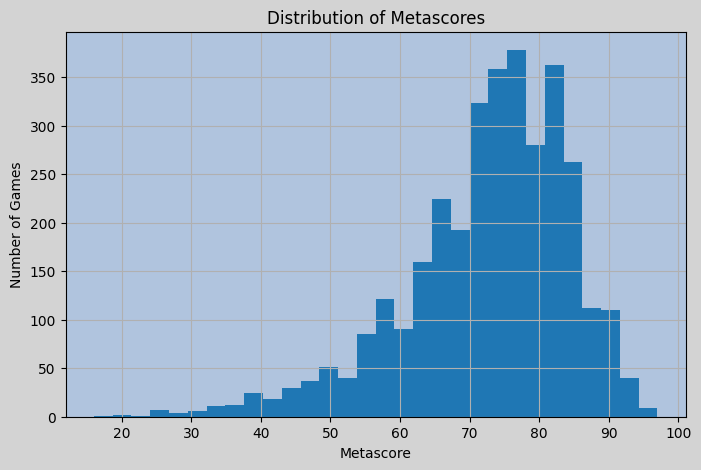

In [791]:
print("mean:", df['metascore'].mean().round(2), "\nmedian:", df['metascore'].median())

plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

df['metascore'].hist(bins=30)
plt.title('Distribution of Metascores')
plt.xlabel('Metascore')
plt.ylabel('Number of Games')
save_figure("metascores-distribution-hist")
plt.show()

### Do critics and users actually agree?

If points form a diagonal line:     critics and users generally agree.

↗

If points are everywhere:           critics and users disagree.

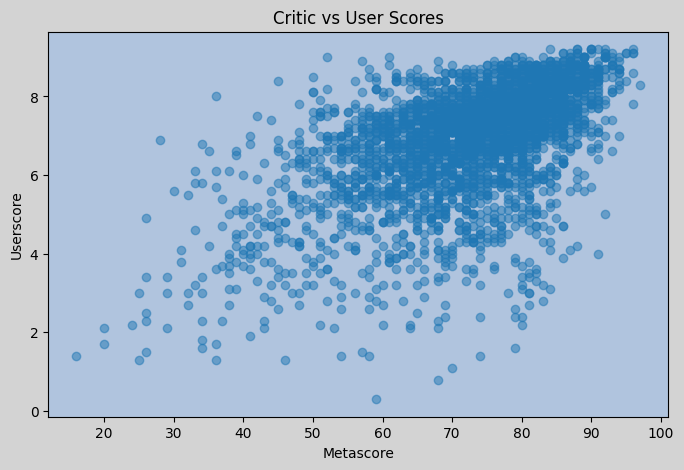

In [792]:
plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

plt.scatter(
    df['metascore'],
    df['userscore'],
    alpha=0.5
)

plt.xlabel('Metascore')
plt.ylabel('Userscore')
plt.title('Critic vs User Scores')
save_figure("metascore-userscore-scatter")
plt.show()

Interpretation:

Correlation	Meaning \
0.9+	extremely strong agreement \
0.7-0.9	strong agreement \
0.5-0.7	moderate \
0.3-0.5	weak \
<0.3	almost unrelated

In [793]:
df['metascore'].corr(df['userscore']).round(4)

np.float64(0.5559)

# 🟢 **Data Analysis**

### 🔹 **Genre Analysis**

exploding the comma-separated genres, developers, distributors

In [794]:
# making separate dataframes for exploding data to avoid biasness in later analysis
genre_df = df.copy()
dev_df = df.copy()
dist_df = df.copy()

# turning comma-separated string into a list of separate items
genre_df['genres'] = genre_df['genres'].str.split(',')
dev_df['developer'] = dev_df['developer'].str.split(',')
dist_df['distributor'] = dist_df['distributor'].str.split(',')


# exploding the lists into their own separate rows
genre_df = genre_df.explode('genres')
dev_df = dev_df.explode('developer')
dist_df = dist_df.explode('distributor')

# stripping the whitespaces out
genre_df['genres'] = genre_df['genres'].str.strip()
dev_df['developer'] = dev_df['developer'].str.strip()
dist_df['distributor'] = dist_df['distributor'].str.strip()

#### ❓ Which genres score highest on average — by critics and by users separately?   Which genres score highest on average — by critics and by users separately? 

In [795]:
# getting the list of genres with 10 or more counts
counts = genre_df['genres'].value_counts()
valid_genres = counts[counts >= 30].index

# filtering the DataFrame
genre_df = genre_df[genre_df['genres'].isin(valid_genres)]
genre_df

,name,distributor,developer,metascore,userscore,genres,rating,release_year,release_month
0,disco-elysium-the-final-cut,ZA/UM,ZA/UM,97.0,8.3,Role-Playing,M,2021,March
0,disco-elysium-the-final-cut,ZA/UM,ZA/UM,97.0,8.3,General,M,2021,March
0,disco-elysium-the-final-cut,ZA/UM,ZA/UM,97.0,8.3,Western-Style,M,2021,March
1,half-life-2,VU Games,Valve Software,96.0,9.2,Action,M,2004,November
1,half-life-2,VU Games,Valve Software,96.0,9.2,Shooter,M,2004,November
...,...,...,...,...,...,...,...,...,...
5290,ride-to-hell-retribution,Deep Silver,"Eutechnyx, Deep Silver",16.0,1.4,Modern,M,2013,June
5290,ride-to-hell-retribution,Deep Silver,"Eutechnyx, Deep Silver",16.0,1.4,Racing,M,2013,June
5290,ride-to-hell-retribution,Deep Silver,"Eutechnyx, Deep Silver",16.0,1.4,Modern,M,2013,June
5290,ride-to-hell-retribution,Deep Silver,"Eutechnyx, Deep Silver",16.0,1.4,Action Adventure,M,2013,June


preparing data

In [796]:
# dropping genres with empty "" strings
genre_df = genre_df[genre_df['genres'] != ""]

# grouping genres with medians of metascores and userscores separately and picking top 10
gb_meta = (genre_df
           .groupby(['genres'])['metascore']
           .median()
           .round(2)
           .sort_values(ascending=False)
           .reset_index()
           )
gb_user = (genre_df
           .groupby(['genres'])['userscore']
           .median()
           .round(2)
           .sort_values(ascending=False)
           .reset_index()
           )

print(gb_meta[3:][::-1], "\n")
print(gb_user[3:][::-1])

                          genres  metascore
61                   Beat-'Em-Up       67.5
60                        Horror       70.0
59                  Third-Person       71.0
58                        Tycoon       71.0
57                            3D       71.0
56             Business / Tycoon       71.0
55                      Survival       71.0
54                        Modern       71.0
53                      Military       72.0
52                        Combat       72.0
51                    Individual       72.0
50                        Linear       73.0
49                       General       73.0
48                     Adventure       73.0
47              Action Adventure       73.0
46                       Shooter       74.0
45                        Arcade       74.0
44                        Action       74.0
43                      Historic       74.0
42                        Flight       74.0
41                      Strategy       74.0
40                      Civilian

saving

In [797]:
# SAVING

with pd.ExcelWriter(specify_dir("genre_scores")) as writer:
    gb_meta.to_excel(writer, sheet_name="Top Genres", startcol=0, startrow=0, index=False)
    next_col = len(gb_meta.columns)
    gb_user.to_excel(writer, sheet_name="Top Genres", startcol=next_col, startrow=0, index=False)

visualizing

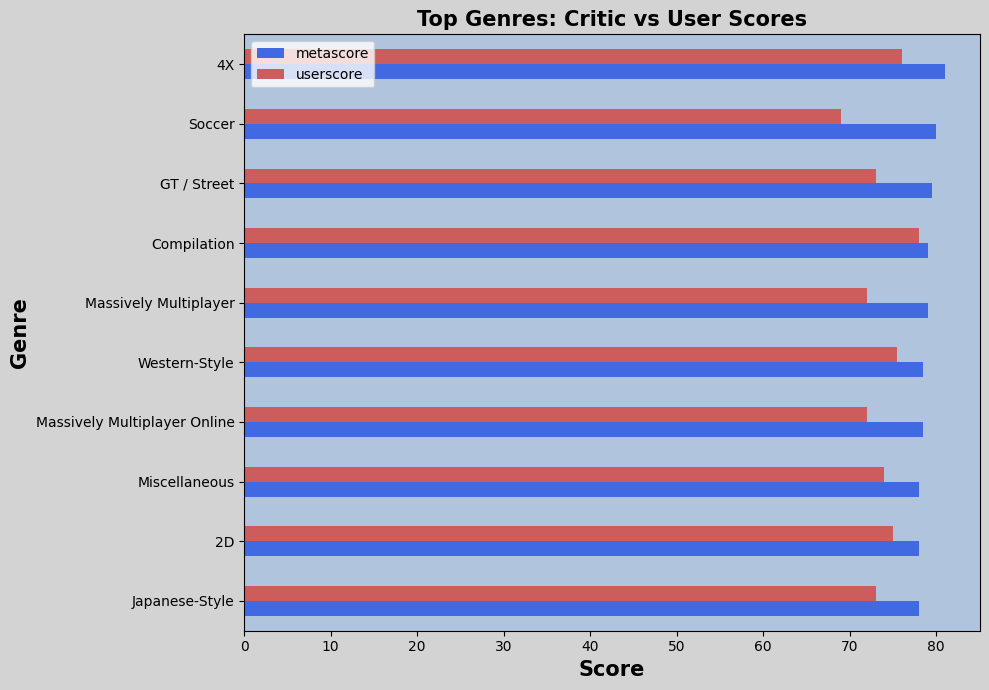

In [798]:
# Visualization

genre_scores = genre_df.groupby('genres')[['metascore', 'userscore']].median()
genre_scores['userscore'] = genre_scores['userscore'] * 10
genre_scores = genre_scores.sort_values('metascore').tail(10)

ax = genre_scores.plot.barh(figsize=(10, 7), color=['royalblue', 'indianred'])
fig = plt.gcf()
fig.patch.set_facecolor('lightgray')
ax.set_facecolor('lightsteelblue')

plt.xlabel("Score", fontdict={'weight':'bold', 'size':15})
plt.ylabel("Genre", fontdict={'weight':'bold', 'size':15})
plt.title("Top Genres: Critic vs User Scores", fontdict={'weight':'bold', 'size':15})
plt.tight_layout()
plt.legend(loc='upper left')
save_figure("top-genres-scores-groupbarh")
plt.show()

#### ❓ Are certain genres systematically underrated by critics but loved by users, or vice versa?

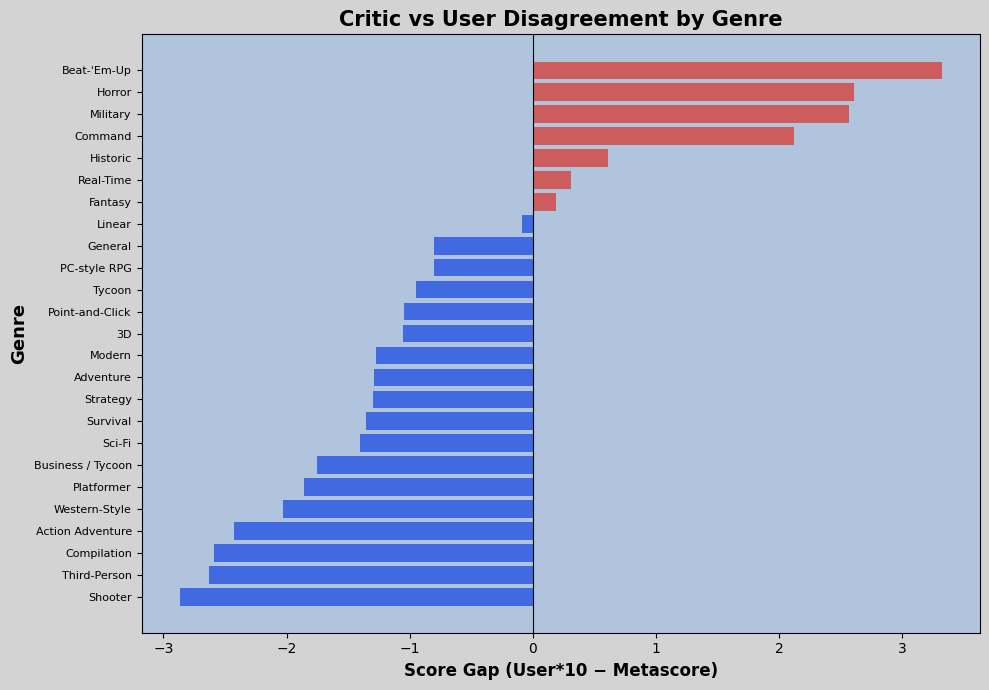

In [799]:
genre_df['score_gap'] = (genre_df['userscore'] * 10) - genre_df['metascore']

genre_gap = (
    genre_df.groupby('genres')['score_gap']
    .mean()
    .sort_values()
)

gg = genre_gap[-25:]
colors = ['royalblue' if v < 0 else 'indianred' for v in gg.values]

# Visualization
# developers with 90+ metascores along with the number of games they developed (Focused on Metascores)
plt.figure(figsize=(10, 7), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

plt.barh(gg.index, gg.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Score Gap (User*10 − Metascore)", fontweight='bold', fontsize=12)
plt.ylabel("Genre", fontweight='bold', fontsize=13)
plt.title("Critic vs User Disagreement by Genre", fontweight='bold', fontsize=15)
plt.yticks(fontsize=8)
plt.tight_layout()
save_figure("genre-score-gap-divergingbarh")
plt.show()

saving

In [800]:
# SAVING
genre_gap.to_excel(specify_dir("genre_score_gaps"), sheet_name="Genre Score Gaps")

merging

In [801]:
info_df = pd.DataFrame({"NOTES":            ["Genre Scores",
                                             "1. This sheet has the top genre columns and their metascores and userscores.",
                                             "2. The scores are the medians of the metascores and userscores",
                                             "3. Both scores are sorted from largest to smallest.",
                                             " ",
                                            "Genre Score Gaps",
                                             "1. Genre Score Gaps (sheet#2) are calculated by (Userscores x 10 - Metascores)",
                                             "2. If userscores are greater, we get a positive value, otherwise a negative value",
                                             "3. Positive values show the genres, liked by users but less preferred by critics",
                                             "4. Negative values show the genres that are not liked by the users but the critics scored them high."]})

with pd.ExcelWriter(specify_dir("Genre Analysis"), engine="xlsxwriter") as writer:
    # reading the data
    scores = pd.read_excel(specify_dir("genre_scores"))
    scoregaps = pd.read_excel(specify_dir("genre_score_gaps"))
    # saving as combined
    scores.to_excel(writer, sheet_name="Genre Scores")
    scoregaps.to_excel(writer, sheet_name="Genre Score Gaps")
    # adding readme sheet for sidenotes and info
    info_df.to_excel(writer, sheet_name="README", index=False)

# deleting the separate files
os.remove(specify_dir("genre_scores"))
os.remove(specify_dir("genre_score_gaps"))

### 🔹 **Developer & Distributor**
#### ❓ Which developers have the highest average metascore ?

grouping and saving

In [802]:
# grouping developer and metascores along with the number of games produced as a separate aggregated column 'games'
dev_score = dev_df.groupby('developer')['metascore'].mean().sort_values()
# preview
print(dev_score[::-1][:10])
# saving
dev_score[::-1].to_excel(specify_dir("developers_metascores"), sheet_name="Developers Metascores")

developer
ZA/UM                    97.000000
MPS Labs                 94.000000
SCE Santa Monica         93.000000
DMA Design               93.000000
Polytron Corp.           91.000000
Looking Glass Studios    90.333333
Rockstar North           90.200000
2D Boy                   90.000000
Lead Pursuit             90.000000
Enhance Games            90.000000
Name: metascore, dtype: float64


visualising

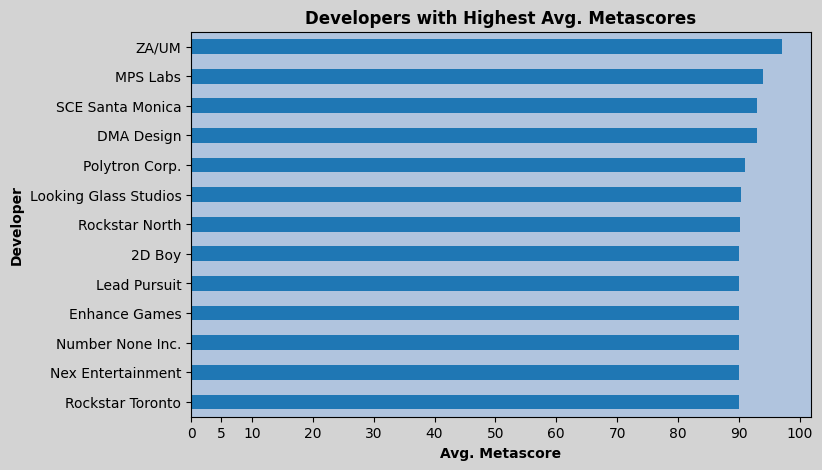

In [803]:
# developers with 90+ metascores along with the number of games they developed (Focused on Metascores)
plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
dev_score[dev_score.values >= 90].plot.barh()
plt.xticks([0,5,10,20,30,40,50,60,70,80,90,100])
plt.xlabel("Avg. Metascore", fontweight='bold')
plt.ylabel("Developer", fontweight='bold')
plt.title("Developers with Highest Avg. Metascores", fontweight='bold')
save_figure("developers-highest-metascores-barh")
plt.show()

#### ❓ Which developers have the highest number of games produced? (min. 70 metascores)

grouping and saving

In [804]:
# developers with highest number of games produced (Focused on Game Count)
dev_game = dev_df.groupby('developer').agg(gamecount = ('name', 'count')).sort_values('gamecount')      # renaming the col 'name' to 'gamecount' using agg to avoid confusion
print("Top Developers with the most games produced:\n", dev_game[::-1][:5]) # previewing
# saving
dev_game[::-1].to_excel(specify_dir("developers_gamecount"), sheet_name="Developers Gamecounts")

Top Developers with the most games produced:
                   gamecount
developer                  
Telltale Games           81
Maxis                    42
Ubisoft Montreal         39
Capcom                   37
Codemasters              36


visualising

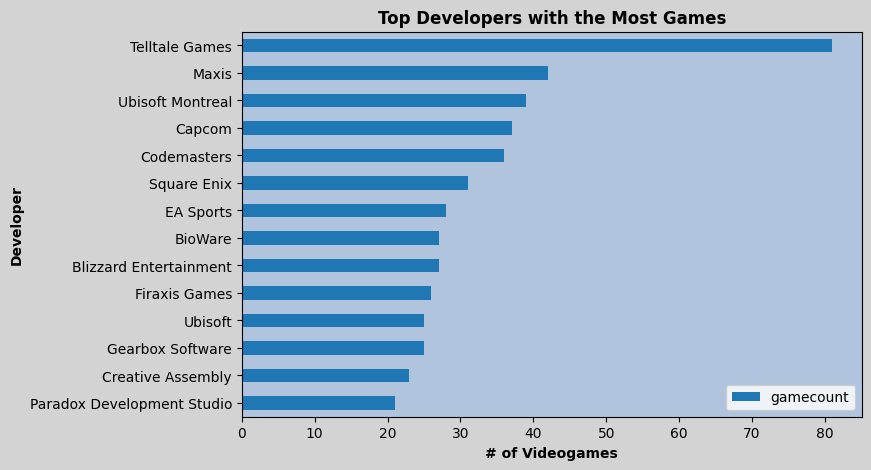

In [805]:
plt.figure(figsize=(8, 5), facecolor='lightgray')
ax = plt.gca()
ax.set_facecolor('lightsteelblue')

dev_game[dev_game.values > 20].plot.barh(ax=ax)

plt.xlabel("# of Videogames", fontweight='bold')
plt.ylabel("Developer", fontweight='bold')
plt.title("Top Developers with the Most Games", fontweight='bold')
save_figure("developers-with-most-games-barh")
plt.show()


#### ❓ Which distributors produce the most critically successful titles?

grouping and saving

In [806]:
dist_score = dist_df.groupby('distributor').agg(
    gamecount = ('name', 'count'),
    metascores = ('metascore', 'mean')
)

# top distributors with highest average of metascores
top_dist = dist_score[(dist_score.gamecount > 5) & (dist_score.metascores > 75)].sort_values('metascores')
print(top_dist[-5:][::-1])      # preview
# saving
top_dist[::-1].to_excel(specify_dir("most_successful_distributors"), sheet_name="Distributors Games & Scores")

                        gamecount  metascores
distributor                                  
Rockstar Games                 13   86.538462
Blizzard Entertainment         25   85.960000
Valve Software                  9   85.777778
GameTap                         8   81.250000
Xbox Game Studios              14   81.000000


visualizing

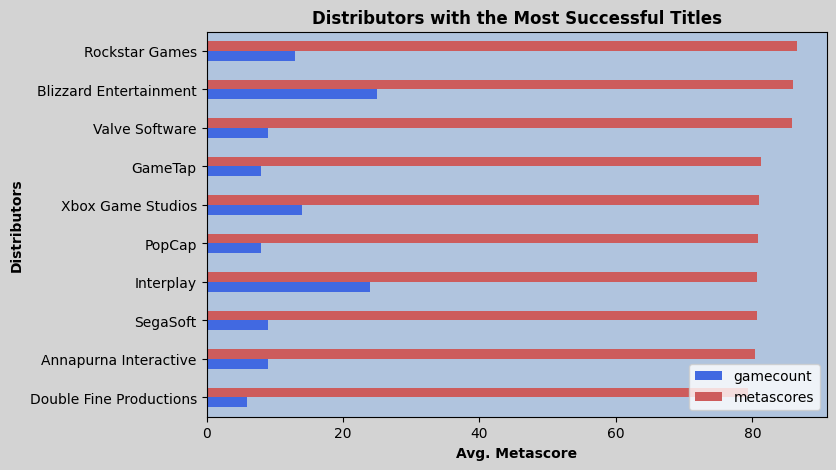

In [807]:
plt.figure(figsize=(8, 5), facecolor='lightgray')
ax = plt.gca()
ax.set_facecolor('lightsteelblue')

top_dist[-10:].plot.barh(ax=ax, color=['royalblue', 'indianred'])
plt.xlabel("Avg. Metascore", fontweight='bold')
plt.ylabel("Distributors", fontweight='bold')
plt.title("Distributors with the Most Successful Titles", fontweight='bold')
save_figure("distributors-with-most-success-barh")
plt.show()

#### ❓ Any studios with consistently declining and improving quality over time?

grouping and saving

In [808]:
# retrieving
gb = dev_df.groupby(['developer', 'release_year'])['metascore'].mean()
dev_years = dev_df.groupby('developer')['release_year'].nunique()
valid_devs = dev_years[dev_years >= 5].index
df_filtered = dev_df[dev_df['developer'].isin(valid_devs)]
gb = df_filtered.groupby(['developer', 'release_year'])['metascore'].mean()
gb = gb.reset_index()

# func to handle trends
def get_trend(group):
    return group['release_year'].corr(group['metascore'])

# applying func to get trends
trends = gb.groupby('developer').apply(get_trend).reset_index()
print("Improving:\n\n", trends.sort_values(0)[::-1][:3], end="\n\n")     # previews
print("Declining:\n\n", trends.sort_values(0)[:3])
trends.rename({0:'correlation'}, inplace=True, axis=1)  # renaming col

# saving
(trends
 .sort_values(by=trends.columns[1], ascending=False)
 .to_excel(specify_dir("developer_trends"), sheet_name="Developer Trends", index=False))

Improving:

            developer         0
66   Giants Software  0.964166
78          Kylotonn  0.868669
143         Treyarch  0.776660

Declining:

            developer         0
28   Criterion Games -0.925789
126       Spellbound -0.895597
42         EA Canada -0.875927


#### ❓ Which Developers are highly inconsistent in their scores?

grouping and saving

In [809]:
# grouping
gb = (dev_df
      .groupby(['developer'])
      .agg(instability = ('metascore', 'std'))
      .sort_values('instability')
      )
gb_filtered = gb[gb.values > 20]
print(gb_filtered)      # preview
# saving
gb[::-1].dropna().to_excel(specify_dir("unstable_developers"), sheet_name="Unstable Developers")

                           instability
developer                             
Naked Sky Entertainment      21.213203
Interceptor Entertainment    21.213203
Old School Games             22.627417
Avalanche Software           23.065125
Prograph                     23.334524
Wizarbox                     23.334524
Guerrilla                    24.041631
Destructive Creations        24.041631
3D Realms                    24.748737
Razorworks                   26.870058
Stormind Games               26.870058
Deep Silver                  28.991378


visualizing

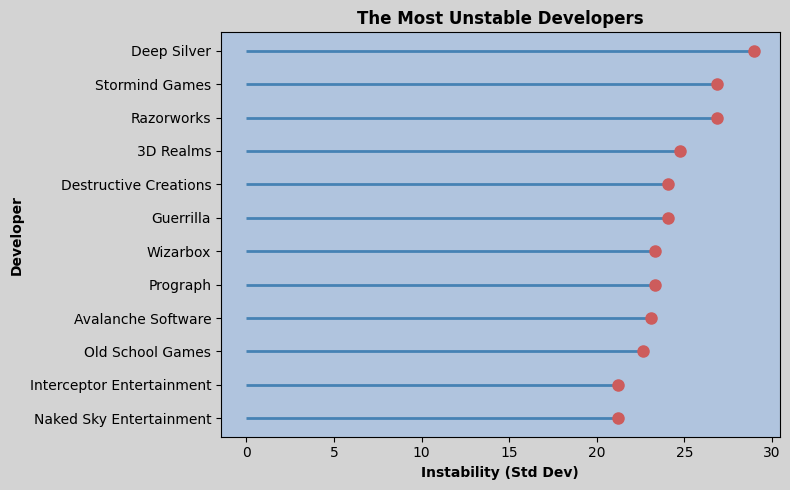

In [810]:
# developers with more than 20 standard deviation of metascores
plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

plt.hlines(gb_filtered.index, 0, gb_filtered.values, color='steelblue', linewidth=2)
plt.plot(gb_filtered.values, gb_filtered.index, 'o', color='indianred', markersize=8)

plt.xlabel("Instability (Std Dev)", fontweight='bold')
plt.ylabel("Developer", fontweight='bold')
plt.title("The Most Unstable Developers", fontweight='bold')
plt.tight_layout()
save_figure("unstable-developers-lolipop")
plt.show()

merging all files into one

In [811]:
info_df = pd.DataFrame({"NOTES":            ["Developers Metascores",
                                             "1. This covers the developers and their top metascores",
                                             "2. The metascores are sorted from highest to lowest",
                                             "3. The metascore column shows the average metascores for each developer",
                                             " ",
                                            "Developers Gamecounts",
                                             "1. It features the developers with the number of games they produced",
                                             "2. The gamecount col is sorted from greatest to smallest",
                                             " ",
                                             "Distributors Games & Scores",
                                             "1. This sheet shows the top distributors with their gamecounts and average metascores",
                                             "2. The distributor col only show the ones with at least 5 games and more than 75 metascore average",
                                             "3. Distributors with less than 5 games and metascore average less tha 75 are not listed",                                             
                                             "4. The data is sorted on metascore column only, because the game count matters only when it's less than or more than 5 counts",
                                             " ",
                                             "Developer Trends",
                                             "1. This sheet focuses on finding the developers with progressing and declining trends over time",
                                             "2. It uses the correlation between release year and metascore means",
                                             "3. Bigger the correlation value, greater the progress is, smaller values show the declining developers",
                                             "4. Correlation column is sorted from highest to lowest. (Negative values show declining devs).",
                                             "Unstable Developers",
                                             "1. This one features the standard deviations of each developer",
                                             "2. This can let us know which developers are inconsistent and varying in their scores",
                                             "3. Higher the std value, the more unstable the developer is",
                                             "4. Column is sorted from highest to lowest, the most unstable developers on top"                                             
                                             ]})

with pd.ExcelWriter(specify_dir("Developer and Distributor Analysis"), engine='xlsxwriter') as writer:
    # reading the files
    dev_meta = pd.read_excel(specify_dir("developers_metascores"))
    dev_gam = pd.read_excel(specify_dir("developers_gamecount"))
    dist = pd.read_excel(specify_dir("most_successful_distributors"))
    trnd = pd.read_excel(specify_dir("developer_trends"))
    unstb = pd.read_excel(specify_dir("unstable_developers"), sheet_name="Unstable Developers")

    # merging as saving as one
    dev_meta.to_excel(writer, sheet_name="Developers Metascores")
    dev_gam.to_excel(writer, sheet_name="Developers Gamecounts")
    dist.to_excel(writer, sheet_name="Distributors Games & Scores")
    trnd.to_excel(writer, sheet_name="Developer Trends")
    unstb.to_excel(writer, sheet_name="Unstable Developers")
    # adding a readme sheet to explain the data and purpose of them
    info_df.to_excel(writer, sheet_name="README", index=False)

# removing the separate files now
os.remove(specify_dir("developers_metascores"))
os.remove(specify_dir("developers_gamecount"))
os.remove(specify_dir("most_successful_distributors"))
os.remove(specify_dir("developer_trends"))
os.remove(specify_dir("unstable_developers"))

### 🔹 **Rating Analysis**

#### ❓ which rating has the highest metascores?

grouping and saving

In [812]:
# grouping
gb = df.groupby('rating').agg(
    games = ('name', 'count'),
    scores = ('metascore', 'mean')
)

print(gb.sort_values('games', ascending=False).reset_index())  # preview

gb = gb.sort_values('games', ascending=False).reset_index()

info_df = pd.DataFrame({"NOTES":["Rating Overview",
                                "1. This includes top ratings sorted by number of games",
                                "2. Next column shows the average metascores for each rating"
                                ]})

# saving
with pd.ExcelWriter(specify_dir("Rating Analysis"), engine='xlsxwriter') as writer:
    gb.to_excel(writer, sheet_name="Rating Overview")
    info_df.to_excel(writer, sheet_name="README", index=False)

  rating  games     scores
0      T   1367  71.835406
1      M   1069  72.395697
2      E    572  73.947552
3   E10+    321  73.601246
4     RP     16  68.062500
5    K-A      6  86.333333
6     AO      1  43.000000


visualizing

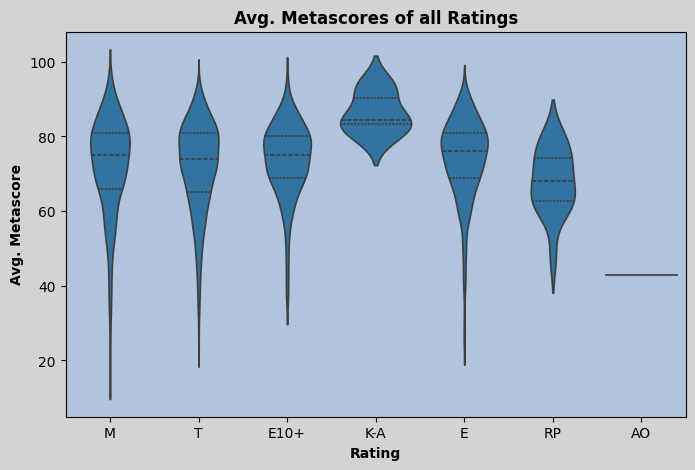

In [813]:
# visualizing
plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
# gb['scores'].sort_values(ascending=False).plot.bar()
sns.violinplot(data=df, x='rating', y='metascore', inner='quartile')

plt.xticks(rotation=0)
plt.xlabel("Rating", fontweight='bold')
plt.ylabel("Avg. Metascore", fontweight='bold')
plt.title("Avg. Metascores of all Ratings", fontweight='bold')
save_figure("metascore-rating-barh")
plt.show()

#### ❓ which rating is mostly used across distributors?

visualizing

rating
T    1581
Name: count, dtype: int64


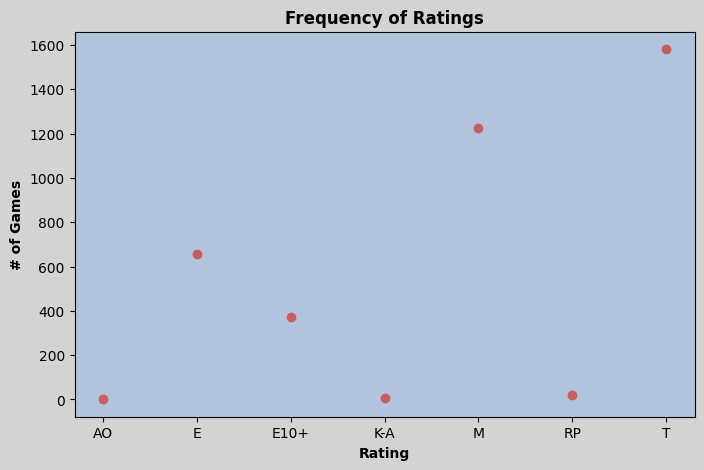

In [814]:
# grouping
gb = dist_df.groupby(['rating'])['distributor'].value_counts()
gb = gb.groupby(level=0).sum()

print(gb.sort_values()[-1:])    # preview

plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
gb.plot(style='o', color='indianred')

plt.xlabel("Rating", fontweight='bold')
plt.ylabel("# of Games", fontweight='bold')
plt.title("Frequency of Ratings", fontweight='bold')
save_figure("rating-frequency-dotplot")
plt.show()

### 🔹 **Time-Based Analysis**

#### ❓ which years had the most liked games?

calculating and saving

In [815]:
year_trends = (df
                .groupby('release_year')[['metascore', 'userscore']]
                .mean()
                .sort_values(['metascore', 'userscore'], ascending=False))

print(year_trends[:10])    # preview

              metascore  userscore
release_year                      
1999          84.928571   8.292857
1998          84.357143   8.457143
1996          83.200000   8.390000
1997          82.923077   8.276923
2022          76.085714   6.093333
2021          75.796748   6.582114
2017          75.223077   6.780000
2019          74.966667   6.509333
2000          74.589744   7.448718
2015          74.564885   6.894656


visualizing

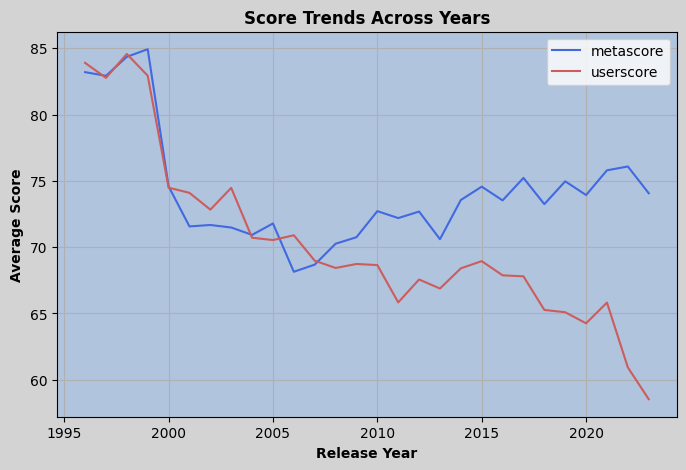

In [816]:
plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')

df.groupby('release_year')['metascore'].mean().plot(color='royalblue')
df.groupby('release_year')['userscore'].mean().mul(10).plot(color='indianred')

plt.xlabel("Release Year", fontweight='bold')
plt.ylabel("Average Score", fontweight='bold')
plt.title("Score Trends Across Years", fontweight='bold')
plt.grid(True)
plt.legend()
save_figure("scores-trends-across-year-plot")
plt.show()

#### ❓ Which months have higher scores (is there any peak around vacations?)

calculating, sorting and Saving

In [817]:
month_map = {"January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6, "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12}
month_map_reverse = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

df['month_num'] = df['release_month'].map(month_map)

# data grouping and sorting
month_trends = (df
                .groupby('month_num')[['metascore', 'userscore']]
                .mean()
                .sort_values(['metascore', 'userscore'], ascending=False)
                .reset_index())

month_trends['month'] = month_trends['month_num'].map(month_map_reverse)
month_trends = month_trends[['month', 'metascore', 'userscore']]

visualizing

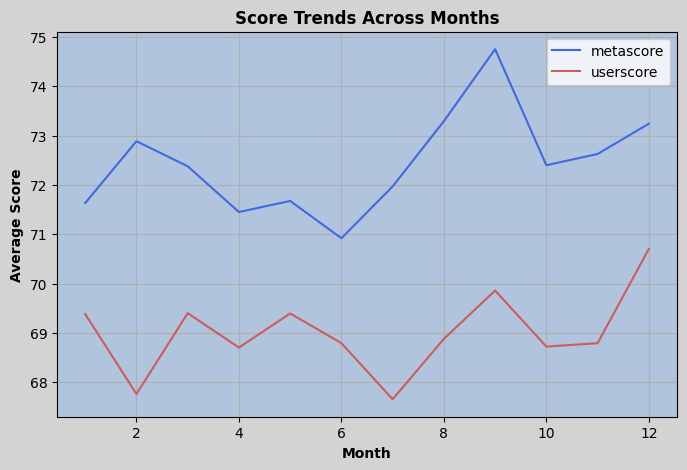

In [818]:
plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
df.groupby(['month_num'])['metascore'].mean().plot(color='royalblue')
df.groupby(['month_num'])['userscore'].mean().mul(10).plot(color='indianred')

plt.xlabel("Month", fontweight='bold')
plt.ylabel("Average Score", fontweight='bold')
plt.title("Score Trends Across Months", fontweight='bold')
plt.grid(True)
plt.legend()
save_figure("score-trends-across-months-plot")
plt.show()

saving

In [819]:
# merging the time-based analysis files into one

info_df = pd.DataFrame({"NOTES":["Yearly Trends",
                                "1. It contains release years from the dataset and give their avg. metascores and avg. userscores",
                                "2. Data is sorted by avg. metascores and then by avg. userscores",
                                "3. Years on the top are with highest scores from critics and users",
                                "4. Lower rows show the years with relatively lower scores on average.",
                                "Monthly Trends",
                                "1. It shows the months sorted by highest avg. metascores and then userscores",
                                "2. Months at the top show higher critic and user preferance for games",
                                "3. The lower months indicate the months with less liked games released",
                                "4. This let us know the best months overall for videogame releases. (including seasons and vacations)"
                                ]})


with pd.ExcelWriter(specify_dir("Time-Based Analysis"), engine='xlsxwriter') as writer:
    year_trends.to_excel(writer, sheet_name="Yearly Trends")
    month_trends.to_excel(writer, sheet_name="Monthly Trends")
    info_df.to_excel(writer, sheet_name="README", index=False)

which games get more positive metascores, with 2 genres only or with multiple (2+)

In [820]:
genre_count = df.genres.str.split(',').apply(lambda x: len(x))
two_genre = df.loc[(genre_count[genre_count == 2]).index]
poly_genre = df.loc[(genre_count[genre_count > 3]).index]

In [821]:
result = [two_genre.metascore.mean() > poly_genre.metascore.mean().round(2)]
print(["Yes, games with 2 genres only get more scores on average than with multiple genres" if result else "No, multiple genre games get more positive scores on average"])

['Yes, games with 2 genres only get more scores on average than with multiple genres']


# 📝 Conclusion

This project transformed raw Metacritic review data into a structured analytical reporting system that combines data cleaning, feature engineering, statistical exploration, visualization, and automated report generation.

Through genre-level, developer-level, distributor-level, rating-based, and time-based analyses, several patterns emerged:

* Critic and user opinions are related, but meaningful disagreements exist within specific genres.
* Genre performance varies considerably depending on whether reception is measured by critics or players.
* High average scores do not necessarily indicate consistency; several developers display large score volatility across releases.
* Long-term trend analysis reveals studios with measurable improvement or decline that would remain hidden in simple averages.
* Distributor performance differs significantly, highlighting publishers that consistently release stronger titles.
* Release timing shows observable differences across years and months, suggesting that reception is influenced by broader industry cycles and release strategies.
* ESRB ratings alone are not strong predictors of review success.

From a technical perspective, the notebook goes beyond traditional EDA by:

* Cleaning and restructuring raw review data
* Engineering temporal features (year and month)
* Handling multi-value categorical fields through explosion techniques
* Creating reusable aggregated datasets
* Generating multiple Excel reporting files with documentation sheets
* Merging related outputs into consolidated reports
* Automatically exporting analytical tables and visualizations

The final deliverables include cleaned datasets, summary tables, ranking reports, trend analyses, comparison studies, and visualization assets that can be reused for further research, dashboard development, or business-oriented gaming insights.

Overall, this project demonstrates a complete analytical workflow—from raw data ingestion to structured, exportable insights—while answering meaningful questions about game quality, audience perception, studio performance, and industry trends.
